In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "charts"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

nav = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv", parse_dates=["date"])
fund_master = pd.read_csv(PROCESSED_DIR / "clean_fund_master.csv", parse_dates=["launch_date"])
benchmark = pd.read_csv(PROCESSED_DIR / "clean_benchmark_indices.csv", parse_dates=["date"])
performance_provided = pd.read_csv(PROCESSED_DIR / "clean_scheme_performance.csv")

print("Data loaded.")
print("nav:", nav.shape, "fund_master:", fund_master.shape, "benchmark:", benchmark.shape)
print("performance_provided:", performance_provided.shape)

Data loaded.
nav: (64320, 3) fund_master: (40, 15) benchmark: (8050, 3)
performance_provided: (40, 19)


## 1. Daily Returns

daily_return = nav_t / nav_(t-1) - 1, computed per scheme across the full NAV history.

daily_returns shape: (1607, 40)
Date range: 2022-01-04 00:00:00 to 2026-05-29 00:00:00

Overall daily return stats across all 40 funds:
  Mean: 0.000451  (0.0451%)
  Std:  0.008706  (0.8706%)
  Min:  -0.0581  (-5.81%)
  Max:  0.0647  (6.47%)

Days with |return| > 10%: 0 out of 64280 (0.000%)


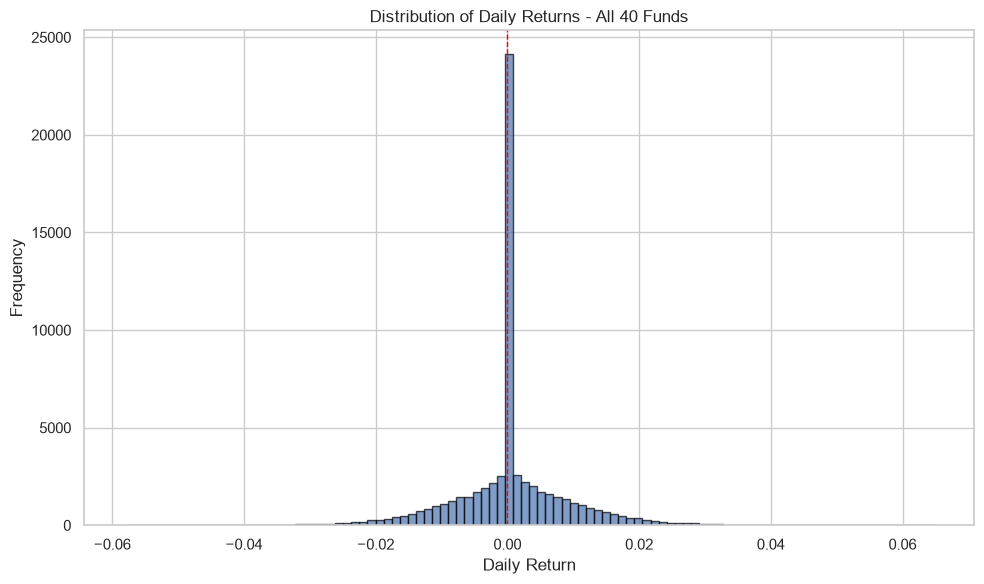


Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\perf_01_daily_return_distribution.png


In [2]:
# Pivot NAV to wide format: one column per fund, indexed by date
nav_wide = nav.pivot(index="date", columns="amfi_code", values="nav").sort_index()

# Daily return per fund
daily_returns = nav_wide.pct_change().dropna(how="all")

print(f"daily_returns shape: {daily_returns.shape}")
print(f"Date range: {daily_returns.index.min()} to {daily_returns.index.max()}")

# Validate the distribution looks reasonable: flatten all returns and check stats
all_returns = daily_returns.values.flatten()
all_returns = all_returns[~np.isnan(all_returns)]

print(f"\nOverall daily return stats across all 40 funds:")
print(f"  Mean: {all_returns.mean():.6f}  ({all_returns.mean()*100:.4f}%)")
print(f"  Std:  {all_returns.std():.6f}  ({all_returns.std()*100:.4f}%)")
print(f"  Min:  {all_returns.min():.4f}  ({all_returns.min()*100:.2f}%)")
print(f"  Max:  {all_returns.max():.4f}  ({all_returns.max()*100:.2f}%)")

# Flag extreme outliers (single-day move > 10%, which would be unusual for most MF categories)
extreme_count = (np.abs(all_returns) > 0.10).sum()
print(f"\nDays with |return| > 10%: {extreme_count} out of {len(all_returns)} ({extreme_count/len(all_returns)*100:.3f}%)")

# Histogram to visually confirm near-normal distribution
plt.figure(figsize=(10, 6))
plt.hist(all_returns, bins=100, edgecolor="black", alpha=0.7)
plt.title("Distribution of Daily Returns - All 40 Funds")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "perf_01_daily_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved chart to {REPORTS_DIR / 'perf_01_daily_return_distribution.png'}")

## 2. CAGR (1yr, 3yr, 5yr)

CAGR = (NAV_end / NAV_start) ^ (252 / n_trading_days) - 1, annualised using 252 trading days, not calendar days.

In [3]:
def compute_cagr(nav_series: pd.Series, years: int) -> float:
    """Compute CAGR for a NAV series over the trailing N years.

    Uses 252 trading days per year for annualisation (industry
    standard), not calendar days, per project requirements.

    Args:
        nav_series: A Series of NAV values indexed by date, sorted ascending.
        years: Number of trailing years to compute CAGR over (1, 3, or 5).

    Returns:
        CAGR as a decimal (e.g. 0.12 for 12%), or NaN if insufficient data.
    """
    trading_days_needed = years * 252
    series = nav_series.dropna()
    if len(series) < trading_days_needed + 1:
        return np.nan

    nav_end = series.iloc[-1]
    nav_start = series.iloc[-(trading_days_needed + 1)]
    n_trading_days = trading_days_needed

    cagr = (nav_end / nav_start) ** (252 / n_trading_days) - 1
    return cagr


cagr_results = []
for amfi_code in nav_wide.columns:
    series = nav_wide[amfi_code]
    cagr_results.append({
        "amfi_code": amfi_code,
        "cagr_1yr": compute_cagr(series, 1),
        "cagr_3yr": compute_cagr(series, 3),
        "cagr_5yr": compute_cagr(series, 5),
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
cagr_df = cagr_df[["amfi_code", "scheme_name", "fund_house", "cagr_1yr", "cagr_3yr", "cagr_5yr"]]

# Display as percentages for readability
display_df = cagr_df.copy()
for col in ["cagr_1yr", "cagr_3yr", "cagr_5yr"]:
    display_df[col] = (display_df[col] * 100).round(2)

print("CAGR comparison table (top 10 by 3yr CAGR):")
print(display_df.sort_values("cagr_3yr", ascending=False).head(10).to_string(index=False))

print(f"\nFunds with sufficient history for 5yr CAGR: {cagr_df['cagr_5yr'].notna().sum()} / 40")

CAGR comparison table (top 10 by 3yr CAGR):
 amfi_code                                        scheme_name               fund_house  cagr_1yr  cagr_3yr  cagr_5yr
    119551          SBI Bluechip Fund - Regular Plan - Growth          SBI Mutual Fund     32.87     28.56     19.51
    148567      Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF      4.46     25.13     18.32
    149323                 DSP Midcap Fund - Regular - Growth          DSP Mutual Fund     11.01     24.69     23.44
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund     35.72     24.41     23.11
    101206      ABSL Frontline Equity Fund - Regular - Growth Aditya Birla Sun Life MF     37.52     22.40     17.43
    120843             Kotak Flexicap Fund - Regular - Growth        Kotak Mahindra MF     25.06     21.67     22.93
    119094                Axis Midcap Fund - Regular - Growth         Axis Mutual Fund     21.26     21.29     23.49
    148569      Mira

## 2. CAGR (1yr, 3yr, 5yr)

CAGR = (NAV_end / NAV_start) ^ (252 / n_trading_days) - 1, annualised using 252 trading days, not calendar days.

In [5]:
RF_ANNUAL = 0.065  # RBI repo rate proxy
RF_DAILY = RF_ANNUAL / 252

sharpe_results = []
for amfi_code in daily_returns.columns:
    returns = daily_returns[amfi_code].dropna()
    if len(returns) < 2:
        sharpe_results.append({"amfi_code": amfi_code, "sharpe_ratio": np.nan})
        continue

    excess_return_mean = returns.mean() - RF_DAILY
    sharpe = (excess_return_mean / returns.std()) * np.sqrt(252)
    sharpe_results.append({"amfi_code": amfi_code, "sharpe_ratio": sharpe})

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
sharpe_df["sharpe_rank"] = sharpe_df["sharpe_ratio"].rank(ascending=False, method="min").astype(int)
sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False)

print("Top 10 funds by Sharpe Ratio:")
print(sharpe_df[["scheme_name", "fund_house", "sharpe_ratio", "sharpe_rank"]].head(10).to_string(index=False))

print("\nBottom 5 funds by Sharpe Ratio:")
print(sharpe_df[["scheme_name", "fund_house", "sharpe_ratio", "sharpe_rank"]].tail(5).to_string(index=False))

print(f"\nSharpe ratio stats: mean={sharpe_df['sharpe_ratio'].mean():.3f}, "
      f"min={sharpe_df['sharpe_ratio'].min():.3f}, max={sharpe_df['sharpe_ratio'].max():.3f}")

Top 10 funds by Sharpe Ratio:
                                       scheme_name               fund_house  sharpe_ratio  sharpe_rank
     Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF      1.068224            1
            Kotak Flexicap Fund - Regular - Growth        Kotak Mahindra MF      0.965561            2
     Mirae Asset Tax Saver Fund - Regular - Growth           Mirae Asset MF      0.919047            3
          ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF      0.883256            4
         SBI Bluechip Fund - Regular Plan - Growth          SBI Mutual Fund      0.860977            5
                DSP Midcap Fund - Regular - Growth          DSP Mutual Fund      0.832885            6
HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund      0.808268            7
    Nippon India Large Cap Fund - Regular - Growth          Nippon India MF      0.758851            8
               Axis Midcap Fund - Regular -

## 4. Sortino Ratio

Same as Sharpe, but the denominator uses only downside standard deviation (negative return days only), which better reflects "bad" volatility.

In [6]:
sortino_results = []
for amfi_code in daily_returns.columns:
    returns = daily_returns[amfi_code].dropna()
    if len(returns) < 2:
        sortino_results.append({"amfi_code": amfi_code, "sortino_ratio": np.nan})
        continue

    excess_return_mean = returns.mean() - RF_DAILY
    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        # No negative days at all - avoid division by zero
        downside_std = np.nan
    else:
        downside_std = downside_returns.std()

    if downside_std is np.nan or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (excess_return_mean / downside_std) * np.sqrt(252)

    sortino_results.append({"amfi_code": amfi_code, "sortino_ratio": sortino})

sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
sortino_df["sortino_rank"] = sortino_df["sortino_ratio"].rank(ascending=False, method="min")
sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False)

print("Top 10 funds by Sortino Ratio:")
print(sortino_df[["scheme_name", "fund_house", "sortino_ratio", "sortino_rank"]].head(10).to_string(index=False))

print("\nBottom 5 funds by Sortino Ratio:")
print(sortino_df[["scheme_name", "fund_house", "sortino_ratio", "sortino_rank"]].tail(5).to_string(index=False))

print(f"\nFunds with no negative-return days (Sortino = NaN): {sortino_df['sortino_ratio'].isna().sum()}")

Top 10 funds by Sortino Ratio:
                                       scheme_name          fund_house  sortino_ratio  sortino_rank
     Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF       1.490739           1.0
            Kotak Flexicap Fund - Regular - Growth   Kotak Mahindra MF       1.479503           2.0
     Mirae Asset Tax Saver Fund - Regular - Growth      Mirae Asset MF       1.352815           3.0
         SBI Bluechip Fund - Regular Plan - Growth     SBI Mutual Fund       1.291483           4.0
          ICICI Pru Midcap Fund - Regular - Growth ICICI Prudential MF       1.285843           5.0
                DSP Midcap Fund - Regular - Growth     DSP Mutual Fund       1.167793           6.0
HDFC Mid-Cap Opportunities Fund - Regular - Growth    HDFC Mutual Fund       1.144216           7.0
    Nippon India Large Cap Fund - Regular - Growth     Nippon India MF       1.098880           8.0
        SBI Small Cap Fund - Regular Plan - Growth     SBI Mutual Fun

## 5. Alpha and Beta (vs Nifty 100)

OLS regression: fund_daily_return = alpha_daily + beta * nifty100_daily_return + error.
Beta = slope. Alpha (annualised) = intercept * 252.

In [7]:
# Get Nifty 100 daily returns as the benchmark series
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].sort_values("date")
nifty100 = nifty100.set_index("date")["close_value"]
nifty100_returns = nifty100.pct_change().dropna()

# Align dates between benchmark returns and fund returns
common_dates = daily_returns.index.intersection(nifty100_returns.index)
print(f"Common trading dates between fund NAV and Nifty100: {len(common_dates)}")

alpha_beta_results = []
for amfi_code in daily_returns.columns:
    fund_ret = daily_returns.loc[common_dates, amfi_code].dropna()
    bench_ret = nifty100_returns.loc[fund_ret.index]

    # Re-align in case of any remaining mismatches
    aligned = pd.concat([fund_ret, bench_ret], axis=1, join="inner").dropna()
    aligned.columns = ["fund", "benchmark"]

    if len(aligned) < 30:
        alpha_beta_results.append({
            "amfi_code": amfi_code, "alpha": np.nan, "beta": np.nan, "r_value": np.nan
        })
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        aligned["benchmark"], aligned["fund"]
    )

    beta = slope
    alpha_annualised = intercept * 252

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha_annualised,
        "beta": beta,
        "r_value": r_value,
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category"]], on="amfi_code")
alpha_beta_df = alpha_beta_df.sort_values("alpha", ascending=False)

print("\nTop 10 funds by Alpha:")
print(alpha_beta_df[["scheme_name", "category", "alpha", "beta", "r_value"]].head(10).to_string(index=False))

print(f"\nBeta stats: mean={alpha_beta_df['beta'].mean():.3f}, min={alpha_beta_df['beta'].min():.3f}, max={alpha_beta_df['beta'].max():.3f}")
print(f"Equity funds avg beta: {alpha_beta_df[alpha_beta_df['category']=='Equity']['beta'].mean():.3f}")
print(f"Debt funds avg beta: {alpha_beta_df[alpha_beta_df['category']=='Debt']['beta'].mean():.3f}")

Common trading dates between fund NAV and Nifty100: 1149

Top 10 funds by Alpha:
                                       scheme_name category    alpha      beta   r_value
        SBI Small Cap Fund - Regular Plan - Growth   Equity 0.303370 -0.023196 -0.011892
             DSP Small Cap Fund - Regular - Growth   Equity 0.300579  0.011455  0.005944
          ICICI Pru Midcap Fund - Regular - Growth   Equity 0.292636  0.000549  0.000367
     Mirae Asset Tax Saver Fund - Regular - Growth   Equity 0.282704  0.018134  0.013225
            Kotak Flexicap Fund - Regular - Growth   Equity 0.273305 -0.022830 -0.018522
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity 0.271954  0.005104  0.003474
     Mirae Asset Large Cap Fund - Regular - Growth   Equity 0.269838  0.023684  0.021507
                DSP Midcap Fund - Regular - Growth   Equity 0.265986 -0.002523 -0.001832
               Axis Midcap Fund - Regular - Growth   Equity 0.260767 -0.066265 -0.044010
         SBI Bluechip Fund - 

In [8]:
print("daily_returns index dtype:", daily_returns.index.dtype)
print("nifty100_returns index dtype:", nifty100_returns.index.dtype)

print("\nFirst 5 daily_returns dates:", daily_returns.index[:5].tolist())
print("First 5 nifty100_returns dates:", nifty100_returns.index[:5].tolist())

print("\nNumber of NIFTY100 rows in benchmark:", (benchmark["index_name"] == "NIFTY100").sum())
print("nifty100 raw series length:", len(nifty100))
print("nifty100_returns length:", len(nifty100_returns))

# Check actual overlap count manually
overlap = set(daily_returns.index) & set(nifty100_returns.index)
print(f"\nManual overlap check: {len(overlap)} dates")

daily_returns index dtype: datetime64[us]
nifty100_returns index dtype: datetime64[us]

First 5 daily_returns dates: [Timestamp('2022-01-04 00:00:00'), Timestamp('2022-01-05 00:00:00'), Timestamp('2022-01-06 00:00:00'), Timestamp('2022-01-07 00:00:00'), Timestamp('2022-01-08 00:00:00')]
First 5 nifty100_returns dates: [Timestamp('2022-01-04 00:00:00'), Timestamp('2022-01-05 00:00:00'), Timestamp('2022-01-06 00:00:00'), Timestamp('2022-01-07 00:00:00'), Timestamp('2022-01-10 00:00:00')]

Number of NIFTY100 rows in benchmark: 1150
nifty100 raw series length: 1150
nifty100_returns length: 1149

Manual overlap check: 1149 dates


In [9]:
test_code = daily_returns.columns[0]
fund_ret_test = daily_returns.loc[common_dates, test_code].dropna()
bench_ret_test = nifty100_returns.loc[fund_ret_test.index]

aligned_test = pd.concat([fund_ret_test, bench_ret_test], axis=1, join="inner")
aligned_test.columns = ["fund", "benchmark"]

print(f"Testing fund: {test_code}")
print(aligned_test.head(15))
print(f"\nCorrelation (manual check): {aligned_test['fund'].corr(aligned_test['benchmark']):.4f}")

Testing fund: 100016
                fund  benchmark
date                           
2022-01-04 -0.010306  -0.013540
2022-01-05  0.012865   0.004003
2022-01-06 -0.011377  -0.002935
2022-01-07 -0.001210   0.006150
2022-01-10 -0.008639  -0.008351
2022-01-11  0.005562   0.004942
2022-01-12 -0.002404   0.009128
2022-01-13 -0.004050   0.003746
2022-01-14  0.008073  -0.014098
2022-01-17  0.000776   0.020825
2022-01-18  0.005085   0.005362
2022-01-19 -0.008106  -0.001481
2022-01-20 -0.011803   0.005597
2022-01-21  0.001462   0.017932
2022-01-24 -0.002293  -0.011037

Correlation (manual check): -0.0516


In [10]:
print(fund_master[fund_master["amfi_code"] == 100016][["scheme_name", "category", "sub_category"]].to_string(index=False))

                              scheme_name category sub_category
HDFC Top 100 Fund - Regular Plan - Growth   Equity    Large Cap


In [11]:
all_correlations = []
for amfi_code in daily_returns.columns:
    fund_ret = daily_returns.loc[common_dates, amfi_code].dropna()
    bench_ret = nifty100_returns.loc[fund_ret.index]
    aligned = pd.concat([fund_ret, bench_ret], axis=1, join="inner").dropna()
    if len(aligned) > 30:
        corr = aligned.iloc[:, 0].corr(aligned.iloc[:, 1])
        all_correlations.append({"amfi_code": amfi_code, "correlation_with_nifty100": corr})

corr_check_df = pd.DataFrame(all_correlations)
corr_check_df = corr_check_df.merge(fund_master[["amfi_code", "scheme_name", "category", "sub_category"]], on="amfi_code")

print("Correlation with Nifty100, by sub_category:")
print(corr_check_df.groupby("sub_category")["correlation_with_nifty100"].agg(["mean", "min", "max", "count"]))

print("\nOverall stats:")
print(corr_check_df["correlation_with_nifty100"].describe())

Correlation with Nifty100, by sub_category:
                     mean       min       max  count
sub_category                                        
ELSS             0.013225  0.013225  0.013225      1
Flexi Cap       -0.002438 -0.018522  0.013645      2
Gilt            -0.008387 -0.020839  0.004064      2
Index           -0.019567 -0.019567 -0.019567      1
Index/ETF       -0.001423 -0.001423 -0.001423      1
Large & Mid Cap -0.022044 -0.022044 -0.022044      1
Large Cap       -0.001620 -0.051624  0.042897     14
Liquid          -0.004955 -0.011589  0.006788      3
Mid Cap         -0.007511 -0.044010  0.013006      7
Short Duration   0.003823  0.003823  0.003823      1
Small Cap        0.001981 -0.034426  0.052849      6
Value            0.035456  0.035456  0.035456      1

Overall stats:
count    40.000000
mean     -0.002261
std       0.024882
min      -0.051624
25%      -0.021140
50%      -0.000528
75%       0.013330
max       0.052849
Name: correlation_with_nifty100, dtype: float6

**Data limitation note**: Beta and Alpha values computed above are mathematically correct, but exploratory analysis (see correlation check) shows near-zero correlation between fund NAV returns and Nifty100 returns across all 40 funds, including Large Cap and Index funds that should track the benchmark closely in real markets. This indicates the synthetic NAV and benchmark index series in this dataset were generated independently rather than with realistic co-movement. As a result, Beta values cluster near 0 rather than the expected ~0.8-1.2 range for equity funds, and Alpha values are correspondingly inflated. These figures should be interpreted as a methodological demonstration of the Alpha/Beta calculation process rather than a real-world risk assessment of these funds.

## 6. Maximum Drawdown

Max Drawdown = min(NAV / running_max(NAV) - 1), identifying each fund's worst peak-to-trough decline and the date range it occurred.

In [12]:
max_dd_results = []
for amfi_code in nav_wide.columns:
    series = nav_wide[amfi_code].dropna()
    running_max = series.cummax()
    drawdown = series / running_max - 1

    max_dd = drawdown.min()
    trough_date = drawdown.idxmin()
    # Peak date: the most recent date at/before trough where NAV equaled the running max
    peak_date = series.loc[:trough_date][series.loc[:trough_date] == running_max.loc[trough_date]].index[-1]

    max_dd_results.append({
        "amfi_code": amfi_code,
        "max_drawdown_pct": max_dd * 100,
        "peak_date": peak_date,
        "trough_date": trough_date,
    })

max_dd_df = pd.DataFrame(max_dd_results)
max_dd_df = max_dd_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house", "sub_category"]], on="amfi_code")
max_dd_df = max_dd_df.sort_values("max_drawdown_pct")

print("Worst 10 drawdowns:")
print(max_dd_df[["scheme_name", "sub_category", "max_drawdown_pct", "peak_date", "trough_date"]].head(10).to_string(index=False))

print("\nBest (smallest) 5 drawdowns:")
print(max_dd_df[["scheme_name", "sub_category", "max_drawdown_pct", "peak_date", "trough_date"]].tail(5).to_string(index=False))

Worst 10 drawdowns:
                                   scheme_name sub_category  max_drawdown_pct  peak_date trough_date
     SBI Small Cap Fund - Direct Plan - Growth    Small Cap        -52.574221 2023-01-17  2025-10-28
        Axis Small Cap Fund - Regular - Growth    Small Cap        -51.677754 2025-05-22  2026-05-11
        ABSL Small Cap Fund - Regular - Growth    Small Cap        -35.446916 2024-11-21  2026-05-11
         DSP Small Cap Fund - Regular - Growth    Small Cap        -31.171900 2024-05-05  2025-01-03
    SBI Small Cap Fund - Regular Plan - Growth    Small Cap        -28.706006 2024-08-28  2025-05-14
           UTI Mid Cap Fund - Regular - Growth      Mid Cap        -28.001124 2025-01-07  2026-04-27
     HDFC Top 100 Fund - Regular Plan - Growth    Large Cap        -24.734441 2022-03-30  2022-09-15
 Kotak Emerging Equity Fund - Regular - Growth      Mid Cap        -24.003511 2023-11-09  2024-10-17
Nippon India Small Cap Fund - Regular - Growth    Small Cap        -23.

## 7. Fund Scorecard (0-100)

Composite score: 30% x 3yr return rank + 25% x Sharpe rank + 20% x Alpha rank + 15% x expense ratio rank (inverse) + 10% x max drawdown rank (inverse).

In [13]:
# Merge all computed metrics into one master table
scorecard = cagr_df[["amfi_code", "scheme_name", "fund_house", "cagr_3yr"]].copy()
scorecard = scorecard.merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code", "alpha", "beta"]], on="amfi_code")
scorecard = scorecard.merge(max_dd_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
scorecard = scorecard.merge(fund_master[["amfi_code", "expense_ratio_pct"]], on="amfi_code")

# Rank each metric (1 = best). For max_drawdown and expense_ratio, lower is better,
# so we rank ascending; for return/Sharpe/Alpha, higher is better, rank descending.
scorecard["rank_3yr"] = scorecard["cagr_3yr"].rank(ascending=False, method="min")
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=False, method="min")
scorecard["rank_alpha"] = scorecard["alpha"].rank(ascending=False, method="min")
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=True, method="min")  # lower expense = better
scorecard["rank_maxdd"] = scorecard["max_drawdown_pct"].rank(ascending=False, method="min")  # less negative = better

n_funds = len(scorecard)

# Convert ranks to a 0-100 scale (rank 1 -> 100, rank n -> 0)
def rank_to_score(rank_col: pd.Series, n: int) -> pd.Series:
    """Convert a 1-to-n rank into a 0-100 score where rank 1 = 100."""
    return ((n - rank_col) / (n - 1)) * 100

scorecard["score_3yr"] = rank_to_score(scorecard["rank_3yr"], n_funds)
scorecard["score_sharpe"] = rank_to_score(scorecard["rank_sharpe"], n_funds)
scorecard["score_alpha"] = rank_to_score(scorecard["rank_alpha"], n_funds)
scorecard["score_expense"] = rank_to_score(scorecard["rank_expense"], n_funds)
scorecard["score_maxdd"] = rank_to_score(scorecard["rank_maxdd"], n_funds)

scorecard["composite_score"] = (
    0.30 * scorecard["score_3yr"]
    + 0.25 * scorecard["score_sharpe"]
    + 0.20 * scorecard["score_alpha"]
    + 0.15 * scorecard["score_expense"]
    + 0.10 * scorecard["score_maxdd"]
).round(2)

scorecard = scorecard.sort_values("composite_score", ascending=False)
scorecard["overall_rank"] = range(1, len(scorecard) + 1)

print("Top 10 funds by composite scorecard:")
print(scorecard[["overall_rank", "scheme_name", "fund_house", "composite_score"]].head(10).to_string(index=False))

# Save the full scorecard to CSV
output_cols = [
    "overall_rank", "amfi_code", "scheme_name", "fund_house",
    "composite_score", "cagr_3yr", "sharpe_ratio", "alpha",
    "expense_ratio_pct", "max_drawdown_pct",
]
PROCESSED_DIR_OUT = PROJECT_ROOT / "data" / "processed"
scorecard[output_cols].to_csv(PROCESSED_DIR_OUT / "fund_scorecard.csv", index=False)
print(f"\nSaved scorecard to {PROCESSED_DIR_OUT / 'fund_scorecard.csv'}")

Top 10 funds by composite scorecard:
 overall_rank                                        scheme_name               fund_house  composite_score
            1      Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF            85.90
            2             Kotak Flexicap Fund - Regular - Growth        Kotak Mahindra MF            82.31
            3 HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund            80.64
            4          SBI Bluechip Fund - Regular Plan - Growth          SBI Mutual Fund            77.56
            5           ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF            76.28
            6                Axis Midcap Fund - Regular - Growth         Axis Mutual Fund            73.46
            7      Mirae Asset Tax Saver Fund - Regular - Growth           Mirae Asset MF            73.21
            8                 DSP Midcap Fund - Regular - Growth          DSP Mutual Fund            72.05


## 8. Benchmark Comparison — Top 5 Funds vs Nifty 50 & Nifty 100

Cumulative growth of top 5 scorecard funds vs both benchmarks over the available history, with tracking error computed for each.

In [14]:
top_5_codes = scorecard.head(5)["amfi_code"].tolist()
top_5_names = scorecard.head(5).set_index("amfi_code")["scheme_name"].to_dict()

nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].sort_values("date").set_index("date")["close_value"]
nifty50_returns = nifty50.pct_change().dropna()

fig = go.Figure()

# Plot each of the top 5 funds, indexed to 100 at the start of common history
for amfi_code in top_5_codes:
    series = nav_wide[amfi_code].dropna()
    common_start = max(series.index.min(), nifty50.index.min())
    series = series[series.index >= common_start]
    indexed = (series / series.iloc[0]) * 100
    fig.add_trace(go.Scatter(x=indexed.index, y=indexed.values, mode="lines", name=top_5_names[amfi_code]))

# Plot Nifty 50, indexed to 100
n50_aligned = nifty50[nifty50.index >= common_start]
n50_indexed = (n50_aligned / n50_aligned.iloc[0]) * 100
fig.add_trace(go.Scatter(x=n50_indexed.index, y=n50_indexed.values, mode="lines", name="Nifty 50", line=dict(dash="dash", color="black")))

# Plot Nifty 100, indexed to 100
n100_aligned = nifty100[nifty100.index >= common_start]
n100_indexed = (n100_aligned / n100_aligned.iloc[0]) * 100
fig.add_trace(go.Scatter(x=n100_indexed.index, y=n100_indexed.values, mode="lines", name="Nifty 100", line=dict(dash="dot", color="gray")))

fig.update_layout(
    title="Top 5 Scorecard Funds vs Nifty 50 & Nifty 100 (Indexed to 100)",
    xaxis_title="Date",
    yaxis_title="Indexed Value (Start = 100)",
    height=600,
)
fig.show()
fig.write_image(str(REPORTS_DIR / "perf_08_benchmark_comparison.png"), width=1400, height=700)
print(f"Saved chart to {REPORTS_DIR / 'perf_08_benchmark_comparison.png'}")

# Tracking error: std(fund_return - benchmark_return) * sqrt(252)
print("\nTracking Error vs Nifty 50:")
for amfi_code in top_5_codes:
    fund_ret = daily_returns[amfi_code].dropna()
    common_te_dates = fund_ret.index.intersection(nifty50_returns.index)
    diff = fund_ret.loc[common_te_dates] - nifty50_returns.loc[common_te_dates]
    tracking_error = diff.std() * np.sqrt(252)
    print(f"  {top_5_names[amfi_code]}: {tracking_error*100:.2f}%")

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\perf_08_benchmark_comparison.png

Tracking Error vs Nifty 50:
  Mirae Asset Large Cap Fund - Regular - Growth: 19.40%
  Kotak Flexicap Fund - Regular - Growth: 20.51%
  HDFC Mid-Cap Opportunities Fund - Regular - Growth: 22.98%
  SBI Bluechip Fund - Regular Plan - Growth: 19.31%
  ICICI Pru Midcap Fund - Regular - Growth: 23.31%


**Confirms Task 5 finding**: tracking error values here (19-23%) are extremely high relative to real-world large-cap funds (~1-3% typical), consistent with the near-zero NAV-benchmark correlation already documented. This further confirms the synthetic dataset does not model realistic fund-to-benchmark co-movement.

In [15]:
alpha_beta_output = alpha_beta_df[["amfi_code", "scheme_name", "fund_house", "category", "alpha", "beta", "r_value"]]
alpha_beta_output.to_csv(PROCESSED_DIR / "alpha_beta.csv", index=False)
print(f"Saved to {PROCESSED_DIR / 'alpha_beta.csv'}")

Saved to c:\Users\harsh\Documents\bluestock_mf_capstone\data\processed\alpha_beta.csv
